In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
from scipy.optimize import curve_fit
reduced_raw_data = pd.read_csv(r'DATA\RAW\reduced_raw_data.csv')
reduced_raw_data_clean = reduced_raw_data[reduced_raw_data['a'].notna()]
sma_data = reduced_raw_data_clean['a']

Narrow binaries ORB6: 2177
Wide binaries ORB6: 8
Narrow binaries SB9: 501
Wide binaries SB9: 23
popt_w: 64.43857153204422


ValueError: operands could not be broadcast together with shapes (8,) (100,) 

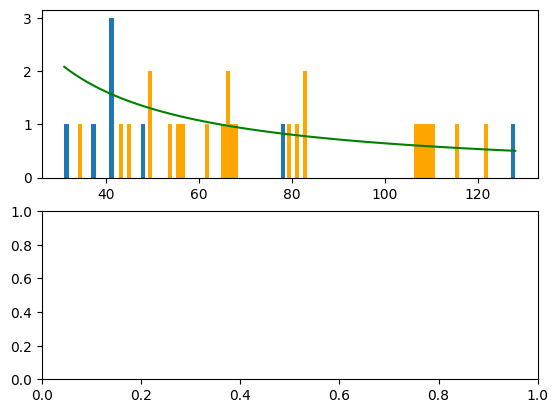

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
from scipy.optimize import curve_fit

def öpik_law(C, a):
    'Distribution for wide binaries'
    N = C*(1/a)
    return N

def log_normal_dist(a, sigma, mu):
    'Log Normal Distribution for narrow binaries'
    N = (1/(np.sqrt(2*np.pi)*sigma))*np.exp(-(((a-mu)/sigma)**2)/2)
    return N

def normal_dist(a, sigma, mu):
    'Normal Distribution for narrow binaries'
    N = (1/(np.sqrt(2*np.pi)*sigma))*np.exp(-(((np.log(a)-mu)/sigma)**2)/2)
    return N

reduced_raw_data = pd.read_csv(r'DATA\RAW\reduced_raw_data.csv')
reduced_raw_data_clean = reduced_raw_data[reduced_raw_data['a'].notna()]
sma_data = reduced_raw_data_clean['a']
sma_data_ORB6 = sma_data[reduced_raw_data['catalogue'].str.contains(r"ORB6", na=False)]
sma_data_SB9 = sma_data[reduced_raw_data['catalogue'].str.contains(r"SB9", na=False)]

narrow_binaries_ORB6 = sma_data_ORB6[sma_data_ORB6 <= 25]
wide_binaries_ORB6 = sma_data_ORB6[sma_data_ORB6 >= 25]
narrow_binaries_SB9 = sma_data_SB9[sma_data_SB9 <= 25]
wide_binaries_SB9 = sma_data_SB9[sma_data_SB9 >= 25]

print(f'Narrow binaries ORB6: {len(narrow_binaries_ORB6)}')
print(f'Wide binaries ORB6: {len(wide_binaries_ORB6)}')
print(f'Narrow binaries SB9: {len(narrow_binaries_SB9)}')
print(f'Wide binaries SB9: {len(wide_binaries_SB9)}')

# ====================================================================================================================
# ORB6 Histogram Analysis
n_bins_w_ORB6 = 100
counts_w_ORB6, bins_w_ORB6 = np.histogram(wide_binaries_ORB6, bins=n_bins_w_ORB6, density=False)
centers_w_ORB6 = (bins_w_ORB6[:-1] + bins_w_ORB6[1:]) / 2

popt_w_ORB6, pcov_w_ORB6 = curve_fit(öpik_law, xdata=centers_w_ORB6[counts_w_ORB6 > 0], ydata=counts_w_ORB6[counts_w_ORB6 > 0])
x_w_ORB6 = np.linspace(min(bins_w_ORB6), max(bins_w_ORB6), n_bins_w_ORB6)
print(f'popt_w: {popt_w_ORB6[0]}')
samples_w_ORB6 = np.random.choice(x_w_ORB6, size=25)
counts_samples_w_ORB6, bins_samples_w_ORB6 = np.histogram(samples_w_ORB6, bins=n_bins_w_ORB6, density=True)

fig, axes = plt.subplots(2,1)
axes[0].hist(wide_binaries_ORB6, bins=n_bins_w_ORB6, density=False, label='Observed Distribution')
axes[0].plot(x_w_ORB6, öpik_law(C=popt_w_ORB6[0], a=x_w_ORB6), label='Öpik Distribution', color='green')
axes[0].hist(samples_w_ORB6, bins=n_bins_w_ORB6, density=False, color='orange', label='Theoretical Distribution')
axes[1].hist(wide_binaries_ORB6-counts_samples_w_ORB6, bins=n_bins_w_ORB6, density=False, label='Bias', color='red')

axes[0].set_ylabel('Counts')
axes[0].set_xlabel('Semi-Major axis [AU]')
axes[0].legend()
fig.suptitle('Bias in Wide Binaries of Binary Star Systems for ORB6')
plt.tight_layout()
plt.show()

# ====================================================================================================================

n_bins_n_ORB6 = 100
counts_n_ORB6, bins_n_ORB6 = np.histogram(narrow_binaries_ORB6, bins=n_bins_n_ORB6, density=True)
centers_n_ORB6 = (bins_n_ORB6[:-1] + bins_n_ORB6[1:]) / 2

popt_n_ORB6, pcov_n_ORB6 = curve_fit(log_normal_dist, xdata=centers_n_ORB6[counts_n_ORB6 > 0], ydata=counts_n_ORB6[counts_n_ORB6 > 0])
x_n_ORB6 = np.linspace(min(bins_n_ORB6), max(bins_n_ORB6), n_bins_n_ORB6)
print(f'popt_n: {popt_n_ORB6}')
samples_n_ORB6 = np.random.choice(x_n_ORB6, size=len(narrow_binaries_ORB6))
counts_samples_n, bins_samples_n = np.histogram(samples_n_ORB6, bins=n_bins_n_ORB6, density=True)

fig, axes = plt.subplots(2,1)
axes[0].hist(narrow_binaries_ORB6, bins=n_bins_n_ORB6, density=True, label='Observed Distribution')
axes[0].plot(x_n_ORB6, log_normal_dist(sigma=popt_n_ORB6[0], mu=popt_n_ORB6[1], a=x_n_ORB6), label='Log-Normal Distribution', color='green')
axes[0].hist(samples_n_ORB6, bins=n_bins_n_ORB6, density=True, color='orange')
axes[0].set_ylabel('Probability')
axes[0].set_xlabel('Semi-Major axis [AU]')
axes[0].legend()
fig.suptitle('Bias in Narrow Binaries of Binary Star Systems for ORB6')
plt.tight_layout()
plt.show()

# ====================================================================================================================
# SB9 Histogram Analysis
n_bins_w_SB9 = 100
counts_w_SB9, bins_w_SB9 = np.histogram(wide_binaries_SB9, bins=n_bins_w_SB9, density=False)
centers_w_SB9 = (bins_w_SB9[:-1] + bins_w_SB9[1:]) / 2

popt_w_SB9, pcov_w_SB9 = curve_fit(öpik_law, xdata=centers_w_SB9[counts_w_SB9 > 0], ydata=counts_w_SB9[counts_w_SB9 > 0])
x_w_SB9 = np.linspace(min(bins_w_SB9), max(bins_w_SB9), n_bins_w_SB9)
print(f'popt_w: {popt_w_SB9[0]}')

fig, axes = plt.subplots(2,1)
axes[0].hist(wide_binaries_SB9, bins=n_bins_w_SB9, density=False, label='Observed Distribution')
axes[0].plot(x_w_SB9, öpik_law(C=popt_w_SB9[0], a=x_w_SB9), label='Öpik Distribution', color='green')
axes[0].set_ylabel('Counts')
axes[0].set_xlabel('Semi-Major axis [AU]')
axes[0].legend()
fig.suptitle('Bias in Wide Binaries of Binary Star Systems for SB9')
plt.tight_layout()
plt.show()

# ====================================================================================================================

n_bins_n_SB9 = 100
counts_n_SB9, bins_n_SB9 = np.histogram(narrow_binaries_SB9, bins=n_bins_n_SB9, density=True)
centers_n_SB9 = (bins_n_SB9[:-1] + bins_n_SB9[1:]) / 2

popt_n_SB9, pcov_n_SB9 = curve_fit(log_normal_dist, xdata=centers_n_SB9[counts_n_SB9 > 0], ydata=counts_n_SB9[counts_n_SB9 > 0])
x_n_SB9 = np.linspace(min(bins_n_SB9), max(bins_n_SB9), n_bins_n_SB9)
print(f'popt_n: {popt_n_SB9}')

fig, axes = plt.subplots(2,1)
axes[0].hist(narrow_binaries_SB9, bins=n_bins_n_SB9, density=True, label='Observed Distribution')
axes[0].plot(x_n_SB9, log_normal_dist(sigma=popt_n_SB9[0], mu=popt_n_SB9[1], a=x_n_SB9), label='Log-Normal Distribution', color='green')
axes[0].set_ylabel('Probability')
axes[0].set_xlabel('Semi-Major axis [AU]')
axes[0].legend()
fig.suptitle('Bias in Narrow Binaries of Binary Star Systems for SB9')
plt.tight_layout()
plt.show()
# ====================================================================================================================